In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [40]:
f=h5py.File('./results_sangria_snr7_1yrs_sel01_tdi15.hdf5', 'r')
print(f.keys())
resolved_sources = f['resolved_sources']

freqs = []
Amps = []
SNRs = []
for source in resolved_sources:
    freqs.append(resolved_sources[source].attrs['f0'])
    Amps.append(resolved_sources[source].attrs['Ampl'])
    SNRs.append(resolved_sources[source].attrs['snr'])


<KeysViewHDF5 ['global_fr', 'history', 'psd_confusion', 'resolved_sources', 'unresolved_indices']>


focus on frequencies, amplitudes, and SNRs of the sources with SNR>7 after iterative subtraction https://arxiv.org/pdf/2103.14598

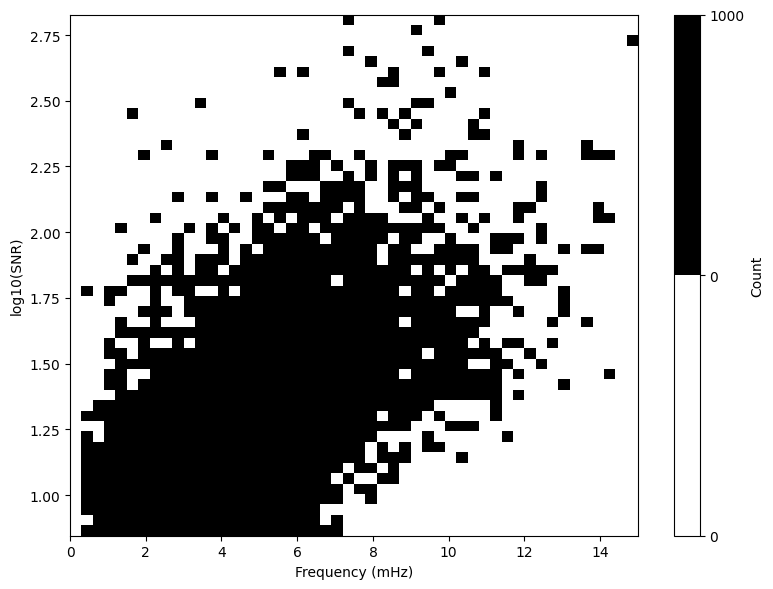

In [41]:
import numpy as np 
fig, ax = plt.subplots(figsize=(8, 6))

from matplotlib.colors import ListedColormap, BoundaryNorm

# Two-color map: white for 0, black for everything else
cmap = ListedColormap(["white", "black"])
norm = BoundaryNorm(boundaries=[0, 0.005, 1000], ncolors=2)

h = ax.hist2d(
    1000*np.array(freqs),
    np.log10(np.array(SNRs)),
    bins=50, # bins=[50, 30],
    range=[[0, 15], [min(np.log10(np.array(SNRs))), max(np.log10(np.array(SNRs)))]],  
    cmap=cmap,
    norm=norm,
    density=False,   
)

fig.colorbar(h[3], ax=ax, label="Count")
ax.set_xlabel("Frequency (mHz)")
ax.set_ylabel("log10(SNR)")

plt.tight_layout()
plt.show()

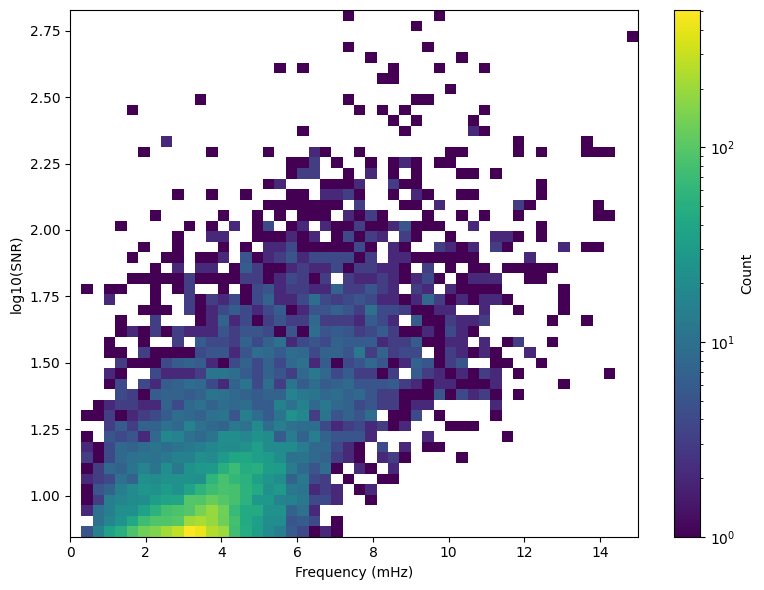

In [42]:
import numpy as np 
fig, ax = plt.subplots(figsize=(8, 6))

h = ax.hist2d(
    1000*np.array(freqs),
    np.log10(np.array(SNRs)),
    bins=50, # bins=[50, 30],
    range=[[0, 15], [min(np.log10(np.array(SNRs))), max(np.log10(np.array(SNRs)))]],  
    cmap='viridis',
    norm='log',
    density=False,   
)

fig.colorbar(h[3], ax=ax, label="Count")
ax.set_xlabel("Frequency (mHz)")
ax.set_ylabel("log10(SNR)")

plt.tight_layout()
plt.show()

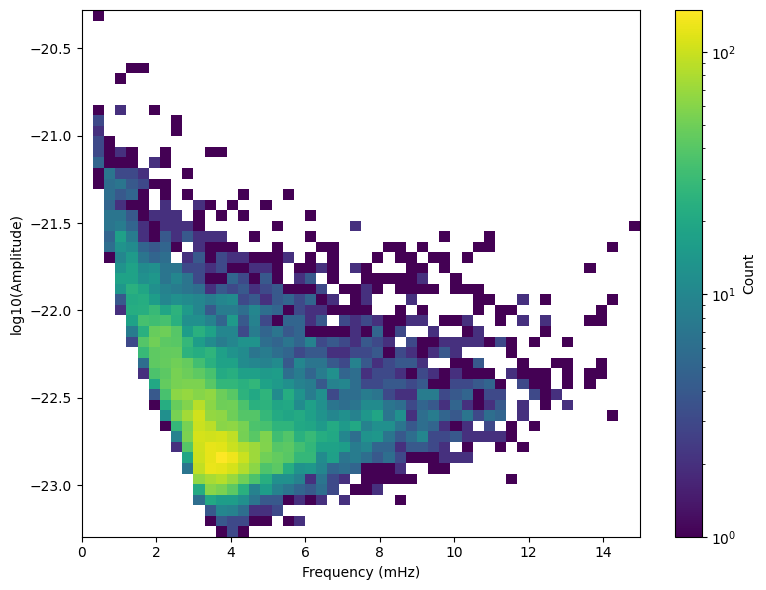

In [43]:
import numpy as np 
fig, ax = plt.subplots(figsize=(8, 6))

h = ax.hist2d(
    1000*np.array(freqs),
    np.log10(np.array(Amps)),
    bins=50, # bins=[50, 30],
    range=[[0, 15], [min(np.log10(np.array(Amps))), max(np.log10(np.array(Amps)))]],  
    cmap='viridis',
    norm='log',
    density=False,   
)

fig.colorbar(h[3], ax=ax, label="Count")
ax.set_xlabel("Frequency (mHz)")
ax.set_ylabel("log10(Amplitude)")

plt.tight_layout()
plt.show()

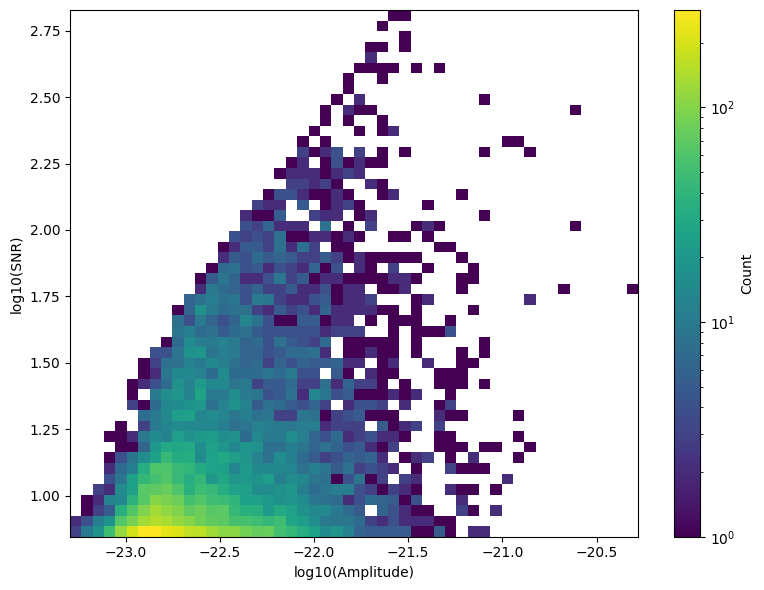

In [44]:
import numpy as np 
fig, ax = plt.subplots(figsize=(8, 6))

h = ax.hist2d(
    np.log10(np.array(Amps)), 
    np.log10(np.array(SNRs)),
    bins=50, # bins=[50, 30],
    cmap='viridis',
    norm='log',
    density=False,   
)

fig.colorbar(h[3], ax=ax, label="Count")
ax.set_xlabel("log10(Amplitude)")
ax.set_ylabel("log10(SNR)")

plt.tight_layout()
plt.show()